In [3]:
import pandas as pd 
import numpy as np

In [4]:
df = pd.read_csv('../../data/raw/extracted_peptides.csv')

In [3]:
df.head()

,sequence,target_activity_name,activity_measure_group,activity
0,RRXXRF,Bacillus subtilis PY22,MIC,4.27708
1,RRXXRF,Escherichia coli DH5alpha,MIC,17.10832
2,KVvvKWVvKvVK,Staphylococcus aureus ATCC 6538P,MIC,165.22899
3,KVvvKWVvKvVK,Bacillus subtilis ATCC 6051,MIC,165.22899
4,KVvvKWVvKvVK,Pseudomonas aeruginosa ATCC 27853,MIC,165.22899


/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


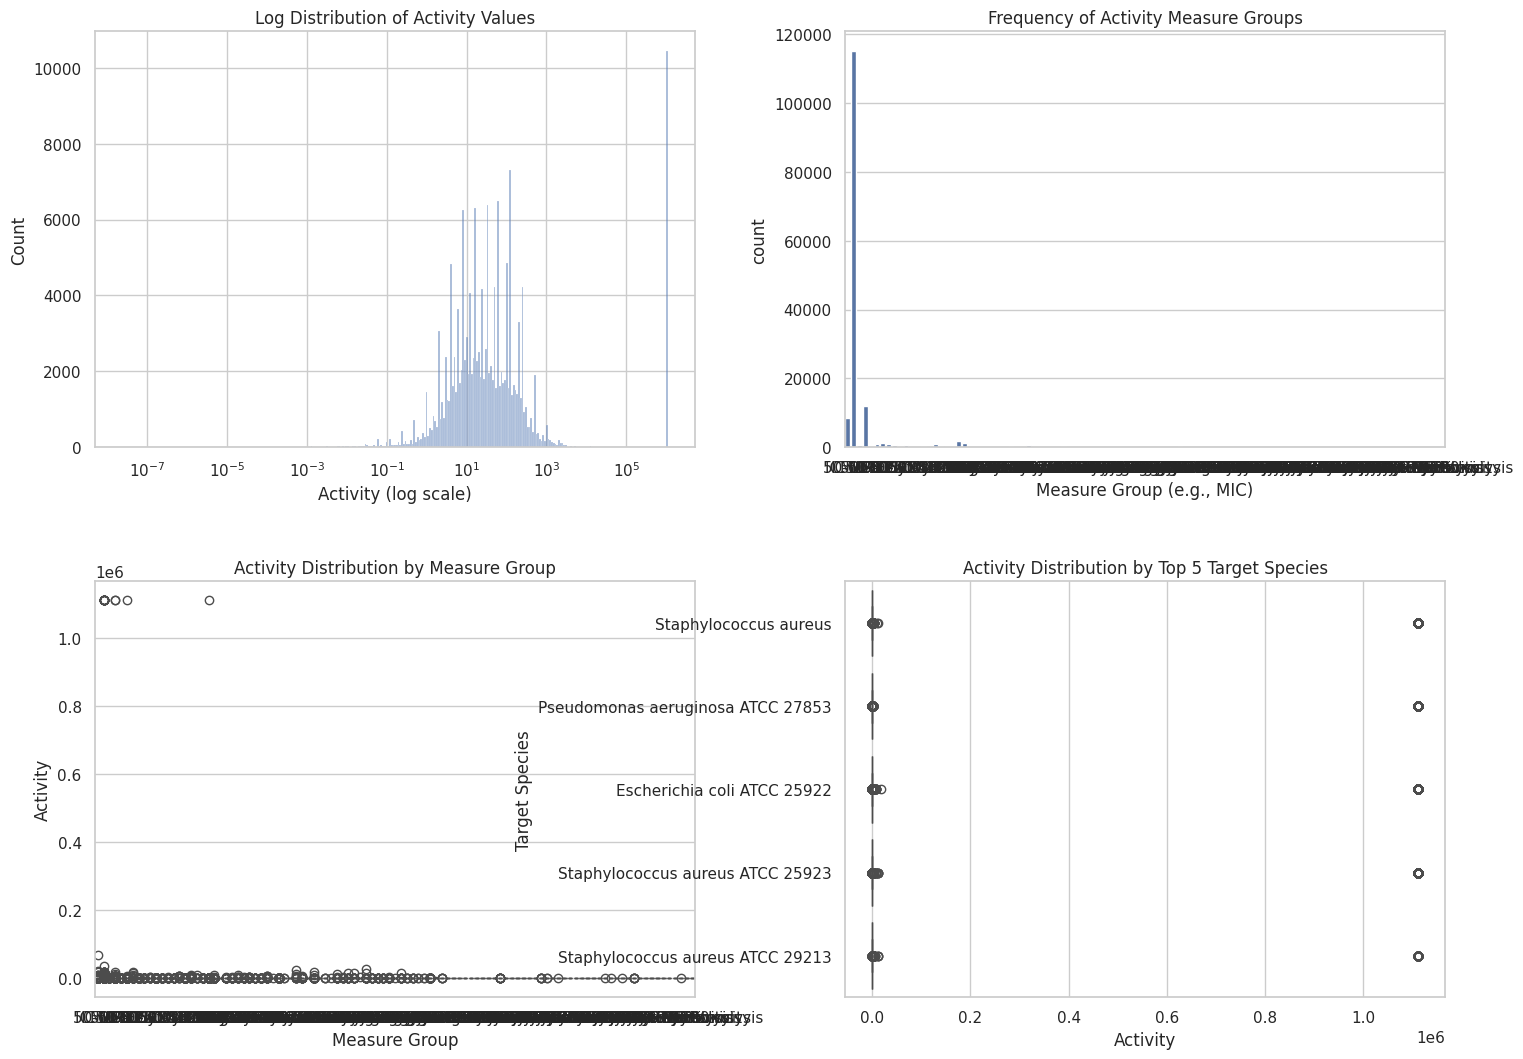

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming your DataFrame is named 'extracted_df' from the previous step
# extracted_df = pd.read_csv('extracted_peptides.csv')

# Set the style for better looking plots
sns.set_theme(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.tight_layout(pad=6.0)

# 1. Histogram of Activity
sns.histplot(data=df, x='activity', log_scale=True, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Log Distribution of Activity Values')
axes[0, 0].set_xlabel('Activity (log scale)')

# 2. Count Plot of Activity Measure Groups
sns.countplot(data=df, x='activity_measure_group', ax=axes[0, 1])
axes[0, 1].set_title('Frequency of Activity Measure Groups')
axes[0, 1].set_xlabel('Measure Group (e.g., MIC)')

# 3. Box Plot: Activity by Measure Group
sns.boxplot(data=df, x='activity_measure_group', y='activity', ax=axes[1, 0])
axes[1, 0].set_title('Activity Distribution by Measure Group')
axes[1, 0].set_xlabel('Measure Group')
axes[1, 0].set_ylabel('Activity')

# 4. Box Plot: Top 5 Target Species by Activity
# First, find the top 5 most frequent species to keep the plot readable
top_species = df['target_activity_name'].value_counts().nlargest(5).index
filtered_df = df[df['target_activity_name'].isin(top_species)]

sns.boxplot(data=filtered_df, y='target_activity_name', x='activity', orient='h', ax=axes[1, 1])
axes[1, 1].set_title('Activity Distribution by Top 5 Target Species')
axes[1, 1].set_ylabel('Target Species')
axes[1, 1].set_xlabel('Activity')

plt.show()

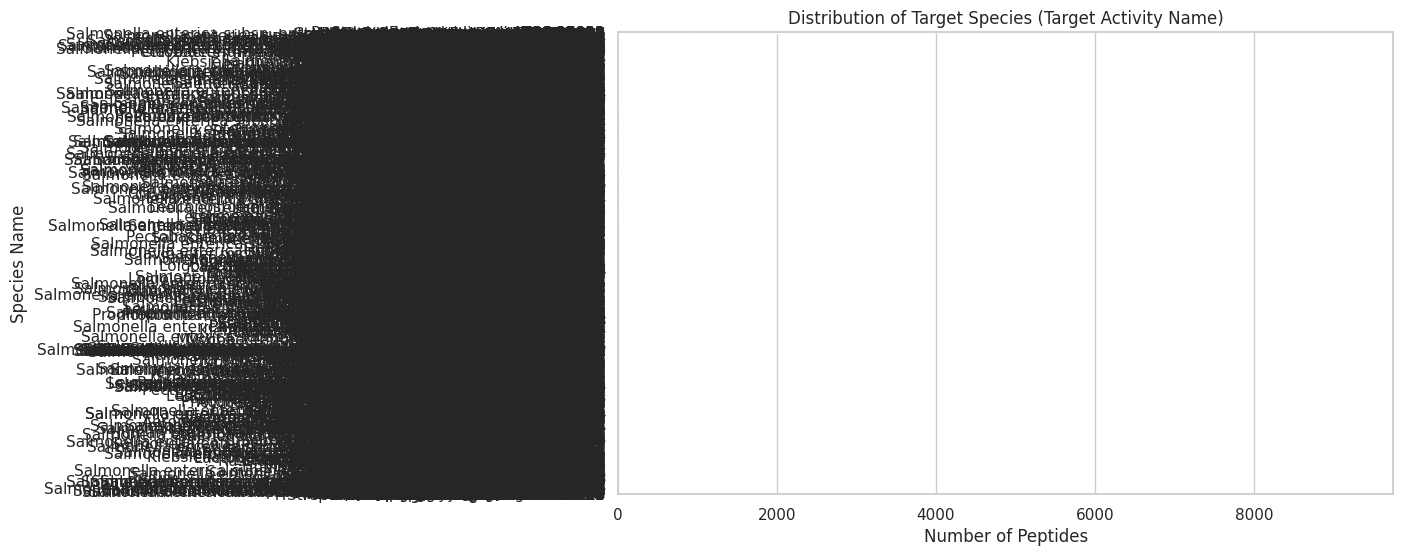

In [6]:
plt.figure(figsize=(10, 6))

# Use countplot to automatically count occurrences of each species
# order=... sorts the bars from highest frequency to lowest
df['target_activity_name'] = df['target_activity_name'].str.replace('\t', ' ', regex=False)

sns.countplot(
    data=df, 
    y='target_activity_name',
    hue='target_activity_name',
    legend=False,
    palette='viridis',
    order=df['target_activity_name'].value_counts().index
)

plt.title('Distribution of Target Species (Target Activity Name)')
plt.xlabel('Number of Peptides')
plt.ylabel('Species Name')
plt.show()

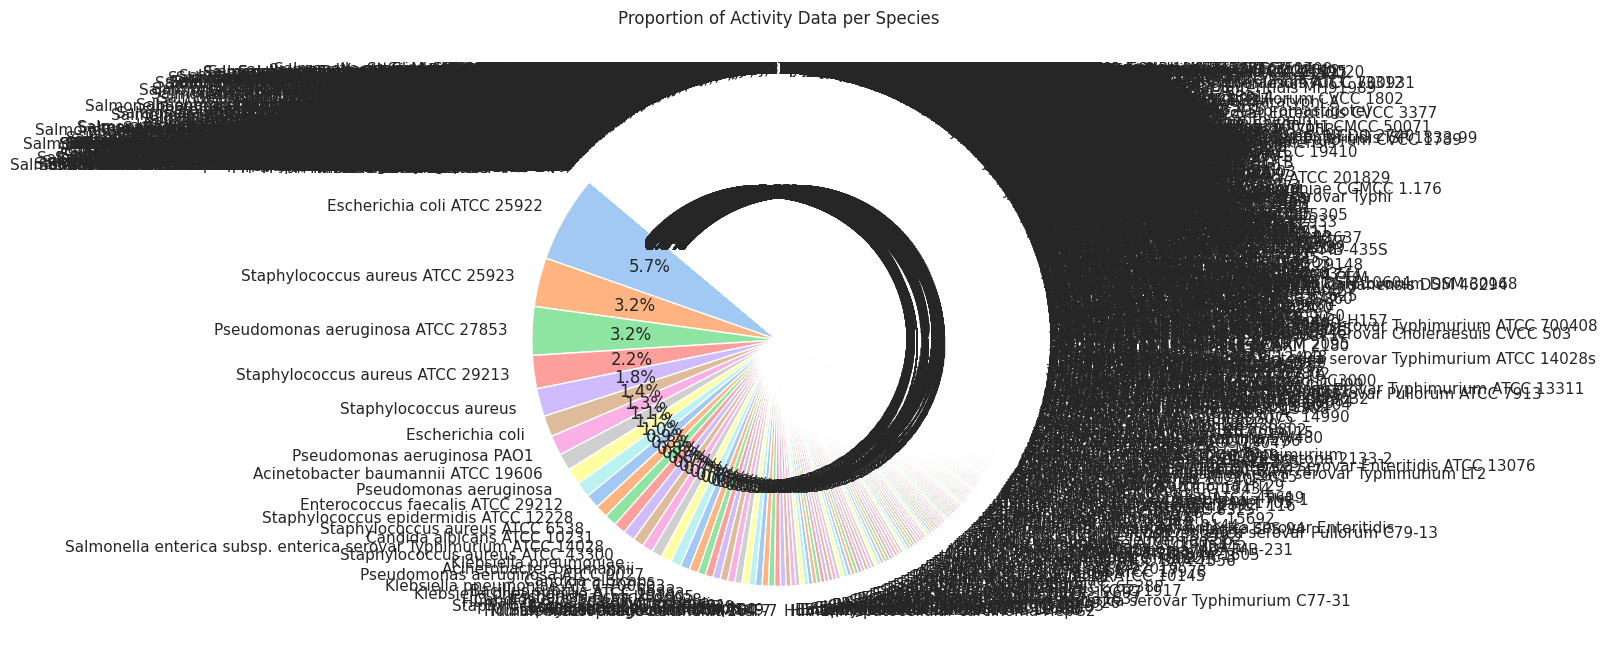

In [7]:
# Get counts
species_counts = df['target_activity_name'].value_counts()

# Plot
plt.figure(figsize=(8, 8))
plt.pie(
    species_counts, 
    labels=species_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette('pastel')
)
plt.title('Proportion of Activity Data per Species')
plt.show()

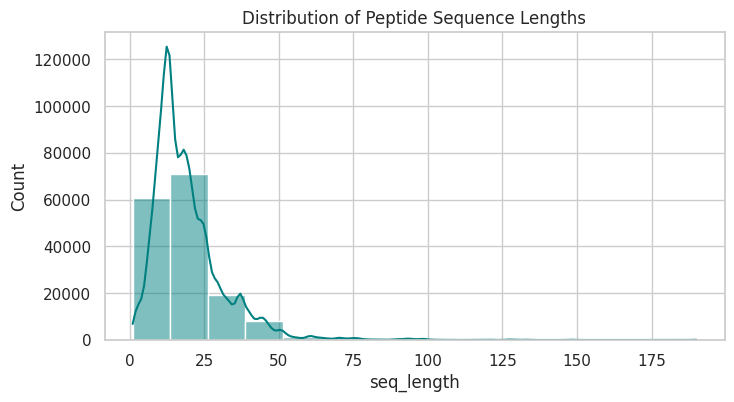

In [8]:
df['seq_length'] = df['sequence'].str.len()

plt.figure(figsize=(8, 4))
sns.histplot(df['seq_length'], bins=15, kde=True, color='teal')
plt.title('Distribution of Peptide Sequence Lengths')
plt.show()

In [20]:

plt.figure(figsize=(20, 30))
# Sort by median activity to make the plot easier to read
# order = df.groupby('activity_measure_group')['activity'].median().sort_values().index[:50] 

sns.boxenplot(data=df[df['activity_measure_group'].isin(order)], 
              x='activity', y='activity_measure_group', palette="viridis")
plt.xscale('log')
plt.title('Activity Distribution across Top 20 Measures (Sorted by Median)')

TypeError: only list-like objects are allowed to be passed to isin(), you passed a `module`

<Figure size 2000x3000 with 0 Axes>

/tmp/ipykernel_6649/3942246681.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='measure', y='count', ax=ax1, palette='Blues_r')


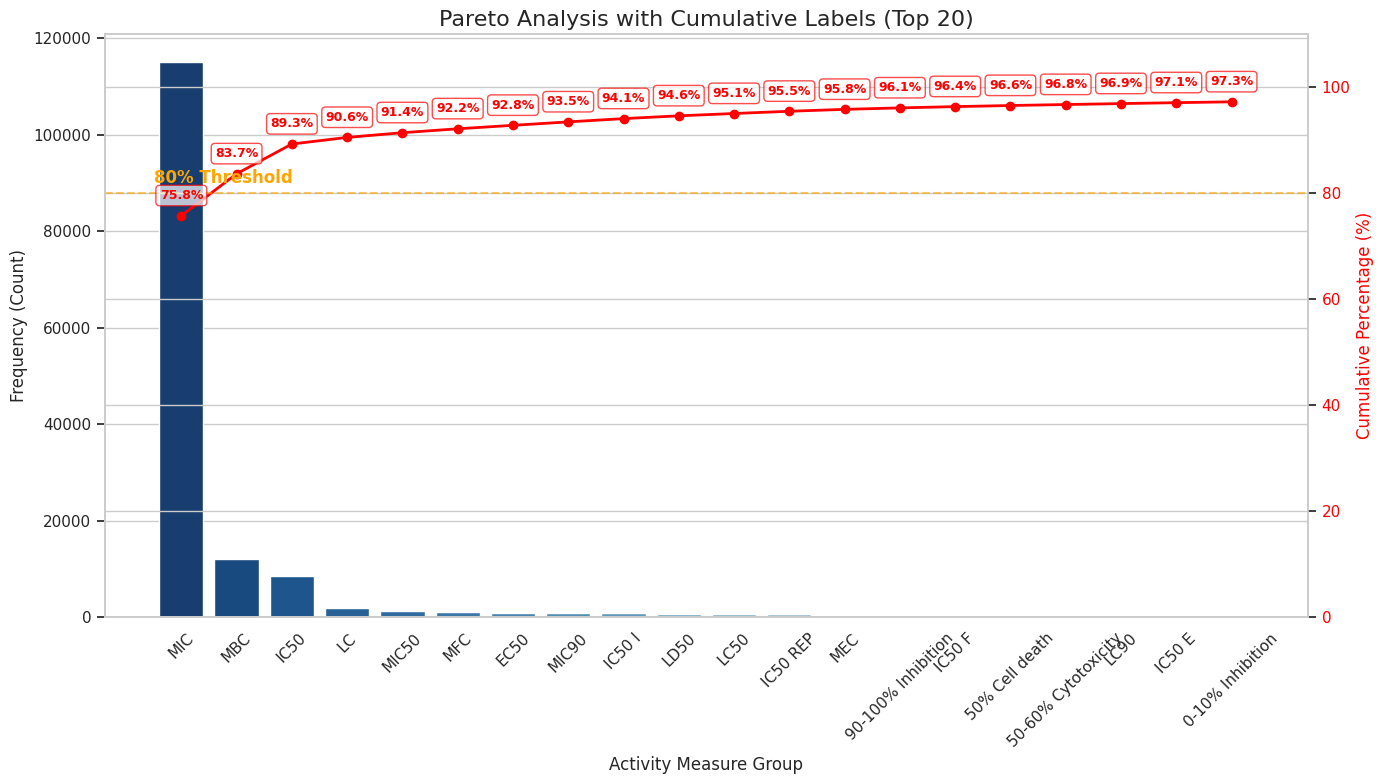

In [11]:

# 1. Prepare the data
counts = df['activity_measure_group'].value_counts().reset_index()
counts.columns = ['measure', 'count']

# Calculate cumulative percentage
total_count = counts['count'].sum()
counts['cum_percent'] = (counts['count'].cumsum() / total_count) * 100

# Slice for the Top 20 for better visibility
top_n = 20
plot_df = counts.head(top_n)

# 2. Initialize the plot
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot the bars (Frequencies)
sns.barplot(data=plot_df, x='measure', y='count', ax=ax1, palette='Blues_r')
ax1.set_ylabel('Frequency (Count)', fontsize=12)
ax1.set_xlabel('Activity Measure Group', fontsize=12)
ax1.tick_params(axis='x', rotation=45)

# 3. Create the secondary Y-axis for the cumulative percentage
ax2 = ax1.twinx()
ax2.plot(plot_df['measure'], plot_df['cum_percent'], color='red', marker='o', linewidth=2, label='Cumulative %')
ax2.set_ylabel('Cumulative Percentage (%)', fontsize=12, color='red')
ax2.set_ylim(0, 110) # Set slightly higher than 100 to leave room for labels
ax2.tick_params(axis='y', labelcolor='red')

# 4. ADD NUMBERS TO THE CUMULATIVE VALUES
for i, val in enumerate(plot_df['cum_percent']):
    ax2.annotate(f'{val:.1f}%', 
                 (i, plot_df['cum_percent'].iloc[i]), 
                 textcoords="offset points", # Position relative to the point
                 xytext=(0, 12),             # 12 points vertical offset
                 ha='center',                # Horizontal alignment
                 fontsize=9, 
                 color='red', 
                 fontweight='bold',
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='red', alpha=0.7)) # Optional background box

# 5. Add a reference line at 80%
ax2.axhline(80, color='orange', linestyle='--', alpha=0.6)
ax2.text(-0.5, 82, '80% Threshold', color='orange', fontweight='bold')

plt.title(f'Pareto Analysis with Cumulative Labels (Top {top_n})', fontsize=16)
plt.tight_layout()
plt.show()

(115078, 5)
(162291, 5)


/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


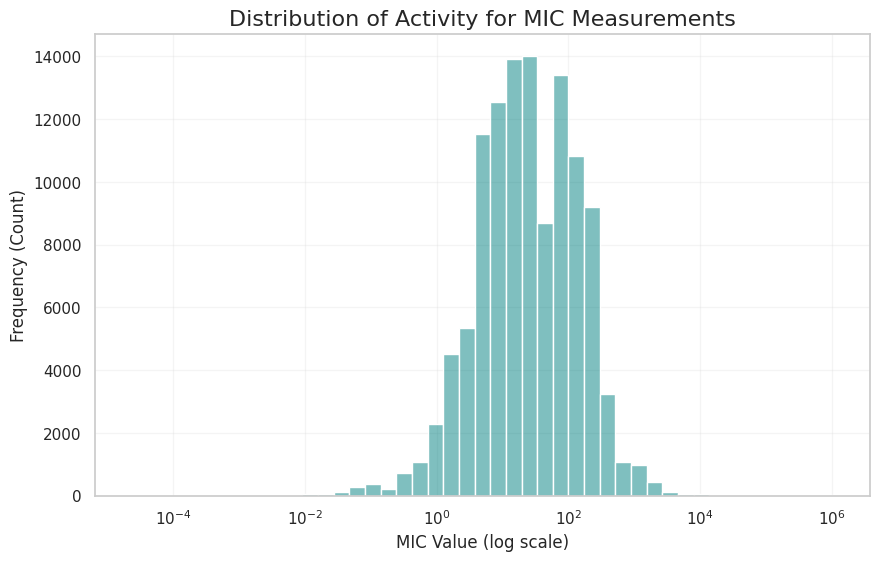

In [12]:
# 1. Filter the data for 'MIC' only
# Note: Ensure the string matches exactly what is in your CSV/DataFrame
mic_df = df[df['activity_measure_group'] == 'MIC']
print(mic_df.shape)
print(df.shape)
# 2. Create the plot
plt.figure(figsize=(10, 6))

sns.histplot(
    data=mic_df, 
    x='activity', 
    log_scale=True,   # Essential for MIC data
    kde=True,         # Adds the Kernel Density Estimate line
    bins=45,
    color='teal',
    edgecolor='white'
)

# 3. Enhance the labels
plt.title('Distribution of Activity for MIC Measurements', fontsize=16)
plt.xlabel('MIC Value (log scale)', fontsize=12)
plt.ylabel('Frequency (Count)', fontsize=12)

# Optional: Add gridlines for better readability on log scale
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda3/lib/python3.13/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/zaza-elizbarashvili/miniconda

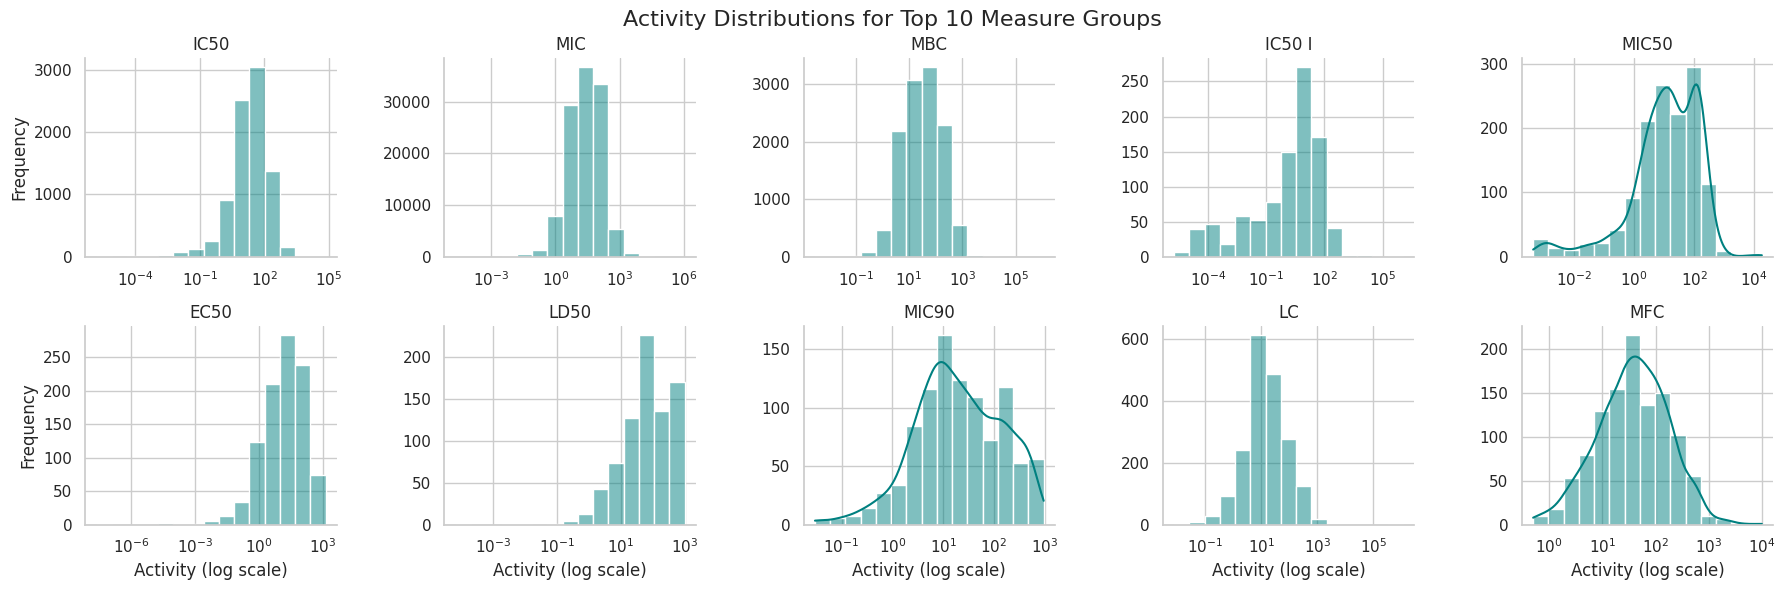

In [13]:
# 1. Identify the Top 10 activity measure groups
top_10_measures = df['activity_measure_group'].value_counts().nlargest(10).index

# 2. Filter the dataframe to include only these 10 groups
df_top10 = df[df['activity_measure_group'].isin(top_10_measures)]

# 3. Create a FacetGrid (Small Multiples)
# col_wrap=5 means it will create 2 rows of 5 plots
g = sns.FacetGrid(df_top10, col="activity_measure_group", col_wrap=5, 
                  sharex=False, sharey=False, height=3, aspect=1.2)

# 4. Map the histogram/KDE to each subplot
# We use log_scale=True because activity values usually span orders of magnitude
g.map_dataframe(sns.histplot, x="activity", log_scale=True, kde=True, 
                bins=15, color='teal', edgecolor='white')

# 5. Final styling
g.set_axis_labels("Activity (log scale)", "Frequency")
g.set_titles(col_template="{col_name}")
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Activity Distributions for Top 10 Measure Groups', fontsize=16)

plt.show()

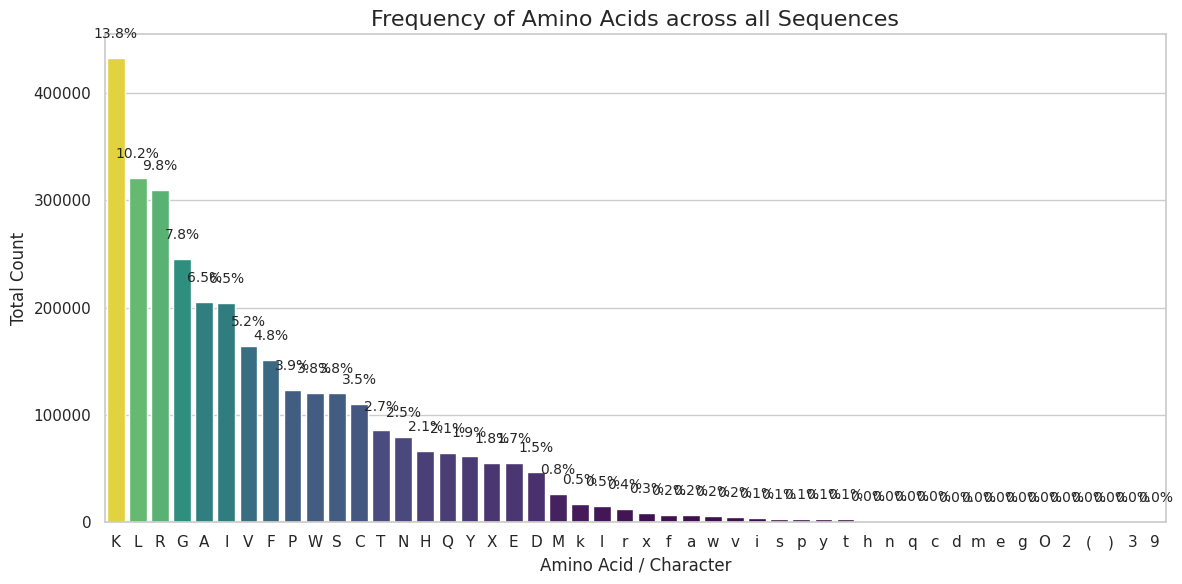

In [14]:
from collections import Counter

# 1. Combine all sequences into one single string
# We drop NA values and ensure everything is a string
all_sequences = "".join(df['sequence'].dropna().astype(str))

# 2. Count the frequency of each character
aa_counts = Counter(all_sequences)

# 3. Convert to a DataFrame for easy plotting
aa_df = pd.DataFrame.from_dict(aa_counts, orient='index').reset_index()
aa_df.columns = ['Amino_Acid', 'Count']

# 4. Sort by frequency (highest to lowest)
aa_df = aa_df.sort_values(by='Count', ascending=False)

# 5. Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(data=aa_df, x='Amino_Acid', y='Count', hue='Count', legend=False, palette='viridis')

# Add labels and title
plt.title("Frequency of Amino Acids across all Sequences", fontsize=16)
plt.xlabel("Amino Acid / Character", fontsize=12)
plt.ylabel("Total Count", fontsize=12)

# Optional: Add the percentage on top of each bar
total_aa = aa_df['Count'].sum()
for i, row in enumerate(aa_df.itertuples()):
    pct = f'{(row.Count / total_aa) * 100:.1f}%'
    plt.text(i, row.Count + (total_aa * 0.005), pct, ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

<Axes: xlabel='R_percent', ylabel='Count'>

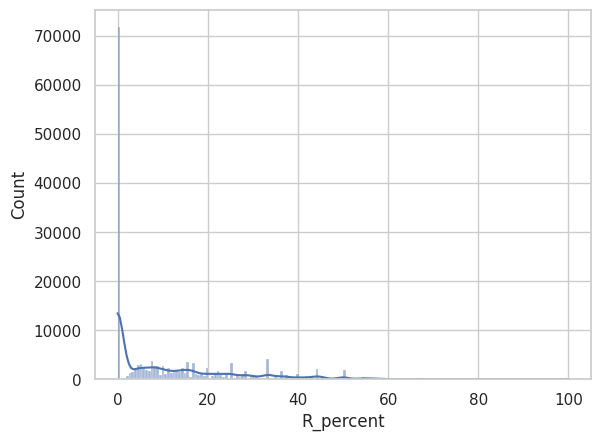

In [15]:
# Create a column for the percentage of Arginine (R) in each peptide
df['R_percent'] = df['sequence'].apply(
    lambda seq: (seq.count('R') / len(seq) * 100) if isinstance(seq, str) and len(seq) > 0 else 0
)

# You can then plot the distribution of 'R_percent'
sns.histplot(df['R_percent'], kde=True)

In [16]:
import re

# Find all unique characters in sequences
all_chars = set(''.join(df['sequence'].dropna()))

lowercase = {c for c in all_chars if c.islower()}
uppercase = {c for c in all_chars if c.isupper()}

print("Lowercase chars found:", lowercase)
print("Uppercase chars found:", uppercase)

Lowercase chars found: {'v', 'l', 'd', 'm', 'c', 'q', 'n', 'p', 'w', 'y', 'g', 'h', 'r', 'i', 't', 's', 'a', 'x', 'k', 'f', 'e'}
Uppercase chars found: {'X', 'A', 'W', 'M', 'T', 'P', 'F', 'I', 'E', 'H', 'S', 'G', 'Y', 'R', 'V', 'O', 'Q', 'N', 'K', 'C', 'D', 'L'}
